In [1]:
from xml.etree.ElementTree import XMLID

import pandas as pd
import numpy as np

from DRP_old import X_train, X_test, y_train, y_pred

In [2]:
mental = pd.read_csv(r'C:\Users\muzam\Downloads\screen_time_mental_health.csv')
items  = pd.read_csv(r'C:\Users\muzam\Downloads\bdi_and_screen_items.csv')

In [8]:
mental.shape


(4810, 10)

In [9]:
items.shape

(4810, 29)

In [11]:
mental.columns.to_list()


['subject_id',
 'sex',
 'screen_time_index',
 'est_leisure_screen_hours',
 'sleep_quality_index',
 'avg_sleep_hours',
 'midsleep_weekend_hours',
 'social_jetlag_hours',
 'bdi_total',
 'depressed']

In [12]:
items.columns.to_list()

['subject_id',
 'screen_normal_day_1to6',
 'screen_weekday_1to6',
 'screen_weekend_1to6',
 'sqi_fall_asleep_1to6',
 'sqi_repeated_awake_1to6',
 'sqi_disturbed_1to6',
 'sqi_early_awake_1to6',
 'bdi_item_01',
 'bdi_item_02',
 'bdi_item_03',
 'bdi_item_04',
 'bdi_item_05',
 'bdi_item_06',
 'bdi_item_07',
 'bdi_item_08',
 'bdi_item_09',
 'bdi_item_10',
 'bdi_item_11',
 'bdi_item_12',
 'bdi_item_13',
 'bdi_item_14',
 'bdi_item_15',
 'bdi_item_16',
 'bdi_item_17',
 'bdi_item_18',
 'bdi_item_19',
 'bdi_item_20',
 'bdi_item_21']

In [13]:
print(mental.shape)
print(items.shape)
print(mental.columns.tolist())
print(items.columns.tolist())

(4810, 10)
(4810, 29)
['subject_id', 'sex', 'screen_time_index', 'est_leisure_screen_hours', 'sleep_quality_index', 'avg_sleep_hours', 'midsleep_weekend_hours', 'social_jetlag_hours', 'bdi_total', 'depressed']
['subject_id', 'screen_normal_day_1to6', 'screen_weekday_1to6', 'screen_weekend_1to6', 'sqi_fall_asleep_1to6', 'sqi_repeated_awake_1to6', 'sqi_disturbed_1to6', 'sqi_early_awake_1to6', 'bdi_item_01', 'bdi_item_02', 'bdi_item_03', 'bdi_item_04', 'bdi_item_05', 'bdi_item_06', 'bdi_item_07', 'bdi_item_08', 'bdi_item_09', 'bdi_item_10', 'bdi_item_11', 'bdi_item_12', 'bdi_item_13', 'bdi_item_14', 'bdi_item_15', 'bdi_item_16', 'bdi_item_17', 'bdi_item_18', 'bdi_item_19', 'bdi_item_20', 'bdi_item_21']


In [14]:
# Cell 1
print("Mental unique IDs:", mental['subject_id'].nunique())
print("Items unique IDs:", items['subject_id'].nunique())

Mental unique IDs: 4810
Items unique IDs: 4810


In [15]:
# Cell 2
print("Mental duplicate IDs:", mental['subject_id'].duplicated().sum())
print("Items duplicate IDs:", items['subject_id'].duplicated().sum())

Mental duplicate IDs: 0
Items duplicate IDs: 0


In [16]:
set(mental['subject_id']) == set(items['subject_id'])

True

In [17]:
df = mental.merge(
    items,
    on='subject_id',
    how='inner'
)

In [18]:
df.shape

(4810, 38)

In [19]:
print(df)

      subject_id   sex  screen_time_index  est_leisure_screen_hours  \
0              1   Boy              3.333                      4.64   
1              2  Girl              3.333                      4.07   
2              3   Boy              3.333                      4.07   
3              4   Boy              4.333                      6.07   
4              5   Boy              1.667                      0.50   
...          ...   ...                ...                       ...   
4805        4806  Girl              2.333                      2.07   
4806        4807   Boy              4.333                      6.07   
4807        4808  Girl              2.333                      2.07   
4808        4809  Girl              3.667                      4.64   
4809        4810   Boy              3.667                      2.93   

      sleep_quality_index  avg_sleep_hours  midsleep_weekend_hours  \
0                    2.25             8.36                    4.58   
1      

In [21]:
bdi_cols = [col for col in df.columns if col.startswith('bdi_item_')]

In [22]:
bdi_cols

['bdi_item_01',
 'bdi_item_02',
 'bdi_item_03',
 'bdi_item_04',
 'bdi_item_05',
 'bdi_item_06',
 'bdi_item_07',
 'bdi_item_08',
 'bdi_item_09',
 'bdi_item_10',
 'bdi_item_11',
 'bdi_item_12',
 'bdi_item_13',
 'bdi_item_14',
 'bdi_item_15',
 'bdi_item_16',
 'bdi_item_17',
 'bdi_item_18',
 'bdi_item_19',
 'bdi_item_20',
 'bdi_item_21']

In [23]:
df_model  = df.drop(
        columns=['bdi_total','subject_id'] + bdi_cols
)

In [24]:
df_model

,sex,screen_time_index,est_leisure_screen_hours,sleep_quality_index,avg_sleep_hours,midsleep_weekend_hours,social_jetlag_hours,depressed,screen_normal_day_1to6,screen_weekday_1to6,screen_weekend_1to6,sqi_fall_asleep_1to6,sqi_repeated_awake_1to6,sqi_disturbed_1to6,sqi_early_awake_1to6
0,Boy,3.333,4.64,2.25,8.36,4.58,1.92,0,2,3,5,1,3,2,3
1,Girl,3.333,4.07,2.50,7.31,5.42,2.25,0,3,3,4,4,2,3,1
2,Boy,3.333,4.07,2.00,8.75,5.50,2.62,1,3,3,4,3,1,3,1
3,Boy,4.333,6.07,1.50,8.17,6.62,3.96,1,4,4,5,2,1,2,1
4,Boy,1.667,0.50,2.50,8.88,4.12,1.79,0,3,1,1,2,2,4,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4805,Girl,2.333,2.07,1.50,8.76,4.08,2.00,1,2,2,3,1,1,3,1
4806,Boy,4.333,6.07,1.00,6.60,7.46,3.46,0,4,4,5,1,1,1,1
4807,Girl,2.333,2.07,1.25,6.61,5.25,1.62,0,2,2,3,2,1,1,1
4808,Girl,3.667,4.64,1.25,7.15,5.54,2.83,0,3,3,5,2,1,1,1


In [25]:
df_model.columns.tolist()

['sex',
 'screen_time_index',
 'est_leisure_screen_hours',
 'sleep_quality_index',
 'avg_sleep_hours',
 'midsleep_weekend_hours',
 'social_jetlag_hours',
 'depressed',
 'screen_normal_day_1to6',
 'screen_weekday_1to6',
 'screen_weekend_1to6',
 'sqi_fall_asleep_1to6',
 'sqi_repeated_awake_1to6',
 'sqi_disturbed_1to6',
 'sqi_early_awake_1to6']

In [26]:
df.shape

(4810, 38)

In [27]:
df_model.info()

<class 'pandas.DataFrame'>
RangeIndex: 4810 entries, 0 to 4809
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   sex                       4810 non-null   str    
 1   screen_time_index         4810 non-null   float64
 2   est_leisure_screen_hours  4810 non-null   float64
 3   sleep_quality_index       4810 non-null   float64
 4   avg_sleep_hours           4810 non-null   float64
 5   midsleep_weekend_hours    4810 non-null   float64
 6   social_jetlag_hours       4810 non-null   float64
 7   depressed                 4810 non-null   int64  
 8   screen_normal_day_1to6    4810 non-null   int64  
 9   screen_weekday_1to6       4810 non-null   int64  
 10  screen_weekend_1to6       4810 non-null   int64  
 11  sqi_fall_asleep_1to6      4810 non-null   int64  
 12  sqi_repeated_awake_1to6   4810 non-null   int64  
 13  sqi_disturbed_1to6        4810 non-null   int64  
 14  sqi_early_awake_1to

In [28]:
df_model.isnull().sum()

sex                         0
screen_time_index           0
est_leisure_screen_hours    0
sleep_quality_index         0
avg_sleep_hours             0
midsleep_weekend_hours      0
social_jetlag_hours         0
depressed                   0
screen_normal_day_1to6      0
screen_weekday_1to6         0
screen_weekend_1to6         0
sqi_fall_asleep_1to6        0
sqi_repeated_awake_1to6     0
sqi_disturbed_1to6          0
sqi_early_awake_1to6        0
dtype: int64

In [29]:
df.duplicated().sum()

np.int64(0)

In [30]:
df_model['depressed'].value_counts()

depressed
0    4023
1     787
Name: count, dtype: int64

In [31]:
df_model['depressed'].value_counts(normalize=True) * 100

depressed
0    83.638254
1    16.361746
Name: proportion, dtype: float64

In [32]:
numeric_df = df_model.select_dtypes(include='number')

In [33]:
corr = numeric_df.corr()

In [34]:
corr

,screen_time_index,est_leisure_screen_hours,sleep_quality_index,avg_sleep_hours,midsleep_weekend_hours,social_jetlag_hours,depressed,screen_normal_day_1to6,screen_weekday_1to6,screen_weekend_1to6,sqi_fall_asleep_1to6,sqi_repeated_awake_1to6,sqi_disturbed_1to6,sqi_early_awake_1to6
screen_time_index,1.000000,0.935067,0.092327,-0.256280,0.286531,0.182000,0.090661,0.702190,0.881334,0.895047,0.106972,0.075995,0.014232,0.074017
est_leisure_screen_hours,0.935067,1.000000,0.071959,-0.227361,0.264168,0.164165,0.066186,0.446258,0.973172,0.873339,0.084223,0.064409,0.007159,0.055393
sleep_quality_index,0.092327,0.071959,1.000000,-0.318088,0.124462,0.022253,0.311798,0.095835,0.058226,0.078230,0.752674,0.807888,0.691947,0.776561
avg_sleep_hours,-0.256280,-0.227361,-0.318088,1.000000,-0.517585,-0.163678,-0.193602,-0.235733,-0.212693,-0.198040,-0.329584,-0.234027,-0.146446,-0.230525
midsleep_weekend_hours,0.286531,0.264168,0.124462,-0.517585,1.000000,0.837755,0.119636,0.218909,0.243204,0.250722,0.174062,0.100451,-0.024033,0.108869
social_jetlag_hours,0.182000,0.164165,0.022253,-0.163678,0.837755,1.000000,0.060671,0.125766,0.142372,0.179251,0.035736,0.030288,-0.050935,0.050966
depressed,0.090661,0.066186,0.311798,-0.193602,0.119636,0.060671,1.000000,0.103778,0.057304,0.069403,0.300065,0.232900,0.126372,0.271658
screen_normal_day_1to6,0.702190,0.446258,0.095835,-0.235733,0.218909,0.125766,0.103778,1.000000,0.424423,0.405199,0.105544,0.066188,0.031298,0.079552
screen_weekday_1to6,0.881334,0.973172,0.058226,-0.212693,0.243204,0.142372,0.057304,0.424423,1.000000,0.752229,0.069877,0.052068,0.001164,0.047586
screen_weekend_1to6,0.895047,0.873339,0.078230,-0.198040,0.250722,0.179251,0.069403,0.405199,0.752229,1.000000,0.092811,0.070580,0.005981,0.059919


In [35]:
corr['depressed'].sort_values(ascending=False)

depressed                   1.000000
sleep_quality_index         0.311798
sqi_fall_asleep_1to6        0.300065
sqi_early_awake_1to6        0.271658
sqi_repeated_awake_1to6     0.232900
sqi_disturbed_1to6          0.126372
midsleep_weekend_hours      0.119636
screen_normal_day_1to6      0.103778
screen_time_index           0.090661
screen_weekend_1to6         0.069403
est_leisure_screen_hours    0.066186
social_jetlag_hours         0.060671
screen_weekday_1to6         0.057304
avg_sleep_hours            -0.193602
Name: depressed, dtype: float64

In [36]:
import numpy as np

upper = corr.where(
    np.triu(np.ones(corr.shape), k=1).astype(bool)
)

high_corr = [
    (col, row, upper.loc[row, col])
    for col in upper.columns
    for row in upper.index
    if pd.notna(upper.loc[row, col]) and abs(upper.loc[row, col]) > 0.80
]

high_corr

[('est_leisure_screen_hours',
  'screen_time_index',
  np.float64(0.9350666164661308)),
 ('social_jetlag_hours',
  'midsleep_weekend_hours',
  np.float64(0.8377545267496486)),
 ('screen_weekday_1to6', 'screen_time_index', np.float64(0.8813343045817602)),
 ('screen_weekday_1to6',
  'est_leisure_screen_hours',
  np.float64(0.9731716377871685)),
 ('screen_weekend_1to6', 'screen_time_index', np.float64(0.8950472415769637)),
 ('screen_weekend_1to6',
  'est_leisure_screen_hours',
  np.float64(0.8733386136773457)),
 ('sqi_repeated_awake_1to6',
  'sleep_quality_index',
  np.float64(0.8078882327842142))]

# Next step: create a cleaner feature set

In [39]:
features = [
    'sex',

    # screen
    'screen_time_index',
    'screen_normal_day_1to6',

    # sleep
    'sleep_quality_index',
    'avg_sleep_hours',
    'midsleep_weekend_hours',

    # raw sleep questions
    'sqi_fall_asleep_1to6',
    'sqi_repeated_awake_1to6',
    'sqi_disturbed_1to6',
    'sqi_early_awake_1to6'
]

X = df_model[features]
y = df_model['depressed']

In [40]:
X.shape

(4810, 10)

In [41]:
X.head()

,sex,screen_time_index,screen_normal_day_1to6,sleep_quality_index,avg_sleep_hours,midsleep_weekend_hours,sqi_fall_asleep_1to6,sqi_repeated_awake_1to6,sqi_disturbed_1to6,sqi_early_awake_1to6
0,Boy,3.333,2,2.25,8.36,4.58,1,3,2,3
1,Girl,3.333,3,2.50,7.31,5.42,4,2,3,1
2,Boy,3.333,3,2.00,8.75,5.50,3,1,3,1
3,Boy,4.333,4,1.50,8.17,6.62,2,1,2,1
4,Boy,1.667,3,2.50,8.88,4.12,2,2,4,2


# Step 6: split the data properly.

In [42]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train , y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [43]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(3848, 10)
(962, 10)
(3848,)
(962,)


In [44]:
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

depressed
0    0.836279
1    0.163721
Name: proportion, dtype: float64
depressed
0    0.836798
1    0.163202
Name: proportion, dtype: float64


In [53]:
from  sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

numeric_features = [
    'screen_time_index',
    'screen_normal_day_1to6',
    'sleep_quality_index',
    'avg_sleep_hours',
    'midsleep_weekend_hours',
    'sqi_fall_asleep_1to6',
    'sqi_repeated_awake_1to6',
    'sqi_disturbed_1to6',
    'sqi_early_awake_1to6'
]

categorical_features = ['sex']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)


In [54]:
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``

# Step 8: build and evaluate the baseline Logistic Regression model.

In [57]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

log_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        random_state=42
    ))
])

In [59]:
log_model.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](10,)","['sex','screen_time_index','screen_normal_day_1to6',..., 'sqi_repeated_awake_1to6','sqi_disturbed_1to6','sqi_early_awake_1to6']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,10
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default o

In [60]:
y_pred = log_model.predict(X_test)
y_prob = log_model.predict_proba(X_test)[:,1]

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

In [61]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.7037422037422038
Precision: 0.30246913580246915
Recall: 0.6242038216560509
F1: 0.4074844074844075
ROC-AUC: 0.7485065474542075

Classification Report:

              precision    recall  f1-score   support

           0       0.91      0.72      0.80       805
           1       0.30      0.62      0.41       157

    accuracy                           0.70       962
   macro avg       0.60      0.67      0.60       962
weighted avg       0.81      0.70      0.74       962



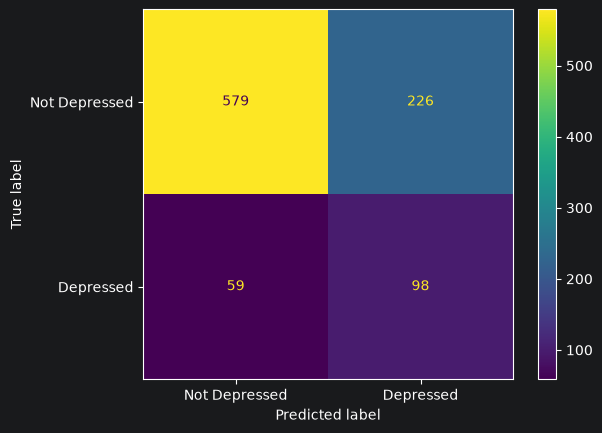

In [62]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=['Not Depressed', 'Depressed']
)

plt.show()

# Step 9 — Compare 3 feature sets

In [63]:
processed_features = [
    'sex',
    'screen_time_index',
    'est_leisure_screen_hours',
    'sleep_quality_index',
    'avg_sleep_hours',
    'midsleep_weekend_hours',
    'social_jetlag_hours'
]

In [64]:
processed_features = [
    'sex',
    'screen_time_index',
    'est_leisure_screen_hours',
    'sleep_quality_index',
    'avg_sleep_hours',
    'midsleep_weekend_hours',
    'social_jetlag_hours'
]

In [65]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

In [66]:
def evaluate_features(feature_list):

    X_temp = df_model[feature_list]

    num_cols = [col for col in feature_list if col != 'sex']
    cat_cols = ['sex']

    prep = ColumnTransformer([
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ])

    pipe = Pipeline([
        ('preprocessor', prep),
        ('classifier', LogisticRegression(
            max_iter=1000,
            class_weight='balanced',
            random_state=42
        ))
    ])

    cv = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

    scores = cross_validate(
        pipe,
        X_temp,
        y,
        cv=cv,
        scoring=['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
    )

    return {
        'Accuracy': scores['test_accuracy'].mean(),
        'Precision': scores['test_precision'].mean(),
        'Recall': scores['test_recall'].mean(),
        'F1': scores['test_f1'].mean(),
        'ROC-AUC': scores['test_roc_auc'].mean()
    }

In [67]:
processed_features = [
    'sex',
    'screen_time_index',
    'est_leisure_screen_hours',
    'sleep_quality_index',
    'avg_sleep_hours',
    'midsleep_weekend_hours',
    'social_jetlag_hours'
]

raw_features = [
    'sex',
    'screen_normal_day_1to6',
    'screen_weekday_1to6',
    'screen_weekend_1to6',
    'sqi_fall_asleep_1to6',
    'sqi_repeated_awake_1to6',
    'sqi_disturbed_1to6',
    'sqi_early_awake_1to6'
]

combined_features = features

In [68]:
comparison = pd.DataFrame({
    'Processed': evaluate_features(processed_features),
    'Raw': evaluate_features(raw_features),
    'Combined': evaluate_features(combined_features)
}).T

comparison

,Accuracy,Precision,Recall,F1,ROC-AUC
Processed,0.716632,0.323450,0.670902,0.436364,0.766522
Raw,0.709979,0.314761,0.655656,0.425199,0.763651
Combined,0.719751,0.325691,0.665823,0.437331,0.772575


In [71]:
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    HistGradientBoostingClassifier
)

models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        random_state=42
    ),

    'Random Forest': RandomForestClassifier(
        n_estimators=300,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ),

    'Gradient Boosting': GradientBoostingClassifier(
        random_state=42
    ),

    'Hist Gradient Boosting': HistGradientBoostingClassifier(
        random_state=42
    )
}